# Kimi K3

Working through the Kimi K3 paper, section by section.

Companion to the [Muon tutorial](../muon-tutorial/muon.ipynb).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

## Table 1: Architectural comparison

Kimi K3 params relevant to inference FLOPs.

In [2]:
k3 = pd.Series(
    {
        "n_layers": 93,
        "n_kda": 69,
        "n_mla": 24,
        "n_dense": 1,
        "d_model": 7_168,
        "d_latent_moe": 3_584,
        "d_ff_expert": 3_072,
        "n_active_routed": 16,
        "n_shared": 2,
        "n_heads": 96,
        "d_vocab": 160_000,
        "seq_len": 1_048_576,
        "n_active_params": 104.2e9,
        "vit_params": 401e6,
        "vit_layers": 27,
        "vit_patch": 14,
        "vit_heads": 12,
    },
    name="Kimi K3",
)

k3

n_layers           9.300000e+01
n_kda              6.900000e+01
n_mla              2.400000e+01
n_dense            1.000000e+00
d_model            7.168000e+03
d_latent_moe       3.584000e+03
d_ff_expert        3.072000e+03
n_active_routed    1.600000e+01
n_shared           2.000000e+00
n_heads            9.600000e+01
d_vocab            1.600000e+05
seq_len            1.048576e+06
n_active_params    1.042000e+11
vit_params         4.010000e+08
vit_layers         2.700000e+01
vit_patch          1.400000e+01
vit_heads          1.200000e+01
Name: Kimi K3, dtype: float64

## Validating 2.78T total / 104.2B active

`models.py` builds the K3 skeleton on `torch.device("meta")` — shapes only, no
storage, so a 2.78T model costs nothing to instantiate. Config values are from
`moonshotai/Kimi-K3` (`k3_config.json`).

In [3]:
from models import K3Config, build, layer_plan

model = build(K3Config())

pd.DataFrame(
    {
        "paper": [2.78e12, 104.2e9],
        "counted": [model.total_params(), model.active_params()],
    },
    index=["total", "active"],
).assign(err=lambda d: (d.counted / d.paper - 1).map("{:+.2%}".format))

,paper,counted,err
total,2.780000e+12,2779482461792,-0.02%
active,1.042000e+11,104187598432,-0.01%


In [4]:
params = pd.DataFrame(
    {"total": model.breakdown(), "active": model.breakdown(active=True)}
).div(1e9)

params.assign(share=lambda d: (d.total / d.total.sum()).map("{:.2%}".format))

,total,active,share
KDA,30.618086,30.618086,1.10%
Gated MLA,5.572706,5.572706,0.20%
MoE routed,2722.740830,48.620372,97.96%
MoE shared,12.155093,12.155093,0.44%
MoE down/up,4.726981,4.726981,0.17%
MoE router,0.591285,0.591285,0.02%
Dense FFN,0.726663,0.726663,0.03%
Embedding,1.174405,0.000000,0.04%
Output head,1.174405,1.174405,0.04%
Other,0.002007,0.002007,0.00%


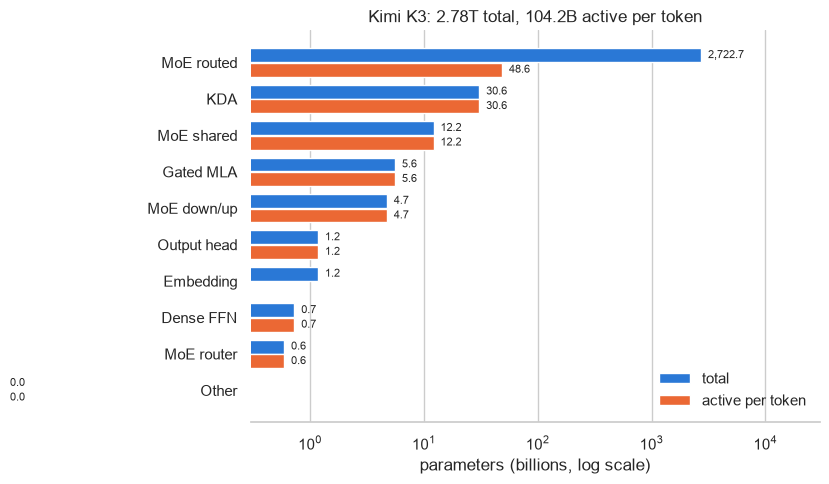

In [5]:
TOTAL, ACTIVE = "#2a78d6", "#eb6834"

d = params.sort_values("total")
y = np.arange(len(d))
h = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(y + h / 2 + 0.01, d.total, h, color=TOTAL, label="total")
ax.barh(y - h / 2 - 0.01, d.active, h, color=ACTIVE, label="active per token")

for yi, (t, a) in enumerate(zip(d.total, d.active)):
    ax.text(t * 1.15, yi + h / 2 + 0.01, f"{t:,.1f}", va="center", fontsize=8)
    if a > 0:
        ax.text(a * 1.15, yi - h / 2 - 0.01, f"{a:,.1f}", va="center", fontsize=8)

ax.set_xscale("log")
ax.set_xlim(0.3, 3e4)
ax.set_yticks(y, d.index)
ax.set_xlabel("parameters (billions, log scale)")
ax.set_title("Kimi K3: 2.78T total, 104.2B active per token")
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="y", visible=False)
sns.despine(left=True)
plt.tight_layout()

## FLOPs from first principles

Everything expensive in a transformer is a matmul, and a matmul has a known cost.

### Rule 0 — one matmul costs `2mkn`

For `A @ B` with `A: (m, k)` and `B: (k, n)`, every one of the `m·n` output cells
is a dot product of length `k`. That dot product is `k` multiplies and `k-1` adds
(the first term initialises the accumulator, it isn't added to anything). So:

$$\text{FLOPs} = m \cdot n \cdot (2k - 1) \;\approx\; 2mkn$$

The standard `2mkn` **rounds up** — it overcounts by exactly `m·n`. That error is
irrelevant once `k` is in the thousands, which is why everyone uses it, but it is
why the counted numbers below come in slightly under the formula.

The cell below runs the triple loop, tallies each multiply and add, and checks the
result against `A @ B`.

In [6]:
from flops import matmul_step, show, softmax_step

A = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 1, 2, 3]], float)
B = np.array([[1, 0, 2, 0, 1], [0, 1, 0, 2, 0], [2, 0, 1, 0, 2], [0, 2, 0, 1, 0]], float)

matmul_step(("A", A), ("B", B), "C", note="15 output cells, each a dot product of length 4");

        A (3x4)                          B (4x5)                             C (3x5)           
    1     2     3     4           1     0     2     0     1           7    10     5     8     7
    5     6     7     8   @       0     1     0     2     0   =      19    22    17    20    19
    9     1     2     3           2     0     1     0     2          13     7    20     5    13
                                  0     2     0     1     0                                    

  shapes      (3x4) @ (4x5) -> (3x5)
  counted     60 mults + 45 adds = 105
  2*m*k*n     2*3*4*5 = 120   (rounds up by m*n = 15)
  note        15 output cells, each a dot product of length 4


### Rule 1 — every weight costs 2 FLOPs per parameter, per token

Push **one** token through a linear layer `y = x @ W`, where `W: (d_in, d_out)`.
That is a matmul with `m = 1`, `k = d_in`, `n = d_out`, so by rule 0:

$$2 \cdot 1 \cdot d_{in} \cdot d_{out} \;=\; 2 \cdot |W|$$

The key move: `d_in · d_out` **is the parameter count of `W`**. The shape that
determines the cost is the same shape that determines the size. So for any stack
of linear layers:

$$\boxed{\;\text{FLOPs per token} \;=\; 2N \quad \text{where } N = \text{params used}\;}$$

This is the whole origin of the two numbers people quote:

| | FLOPs | why |
|---|---|---|
| **forward** | `2N` | one matmul per weight |
| **training** | `6N` | `2N` forward + `4N` backward |

The backward pass is `4N` because it computes **two** gradients per weight — one
w.r.t. the layer's input (to keep propagating) and one w.r.t. the weight itself
(to actually update it) — each costing the same `2N` as the forward matmul.

For K3, `N` is the **activated** 104.2B, not the 2.78T. The 880 experts that
don't fire cost zero FLOPs; they only occupy memory.

In [7]:
x = np.array([[2, 0, 1, 3]], float)  # ONE token
W = np.array([[1, 0, 2], [0, 3, 1], [2, 1, 0], [1, 1, 1]], float)  # the weight

matmul_step(("x  (1 token)", x), ("W  (the weight)", W), "y")

print(f"\n  W holds     {W.size} parameters")
print(f"  2 x params  {2 * W.size}")
print("  m=1 is the trick: k*n IS the parameter count, so 2*1*k*n = 2*|W|")

print("\nsame rule at K3's real shapes:")
for name, (i, o) in {
    "KDA W_q": (7168, 12288),
    "MLA W_kv-down": (7168, 576),
    "routed expert gate": (3584, 3072),
}.items():
    print(f"  {name:20} {i:>5} x {o:<6} {i * o / 1e6:7.2f}M params ->{2 * i * o / 1e6:8.2f} MFLOP/token")

   x  (1 token) (1x4)         W  (the weight) (4x3)            y (1x3)     
                                    1     0     2                          
    2     0     1     3   @         0     3     1     =       7     4     7
                                    2     1     0                          
                                    1     1     1                          

  shapes      (1x4) @ (4x3) -> (1x3)
  counted     12 mults + 9 adds = 21
  2*m*k*n     2*1*4*3 = 24   (rounds up by m*n = 3)

  W holds     12 parameters
  2 x params  24
  m=1 is the trick: k*n IS the parameter count, so 2*1*k*n = 2*|W|

same rule at K3's real shapes:
  KDA W_q               7168 x 12288    88.08M params ->  176.16 MFLOP/token
  MLA W_kv-down         7168 x 576       4.13M params ->    8.26 MFLOP/token
  routed expert gate    3584 x 3072     11.01M params ->   22.02 MFLOP/token


### Rule 2 — attention scores have no weights, so they escape `2N`

Rule 1 worked because one operand of the matmul was a *weight*. Inside attention,
**both operands are activations**:

```
scores = Q @ K.T        no parameters
out    = attn @ V       no parameters
```

`Q`, `K` and `V` are things the model computed from the current input, not things
it learned. (The weights that *produced* them — `W_q`, `W_k`, `W_v` — already got
counted under rule 1. These two matmuls are extra, on top.) So this cost is
**invisible to `2N`** — there is no parameter to multiply by 2. Apply rule 0
directly instead, and the answer depends on the regime:

| | `Q` shape | scores shape | FLOPs |
|---|---|---|---|
| **prefill** — all `s` tokens at once | `(s, d_k)` | `(s, s)` | `2s^2(d_k + d_v)` |
| **decode** — one new token vs `s` cached | `(1, d_k)` | `(1, s)` | `2s(d_k + d_v)` |

Prefill is **quadratic** in context, decode is **linear** — but decode runs once
per generated token, so a full generation reaches the same `O(s²)`.

The cell below walks the prefill case with real numbers so the shapes are visible:
`Q @ K.T` → softmax → `@ V`. Watch the `s×s` matrix appear in the middle — that
square is the entire long-context problem.

In [8]:
s, d_k, d_v = 4, 3, 2  # 4 tokens, key dim 3, value dim 2

Q = np.array([[1, 0, 2], [0, 2, 1], [2, 1, 0], [1, 1, 1]], float)
K = np.array([[1, 1, 0], [0, 1, 2], [2, 0, 1], [1, 2, 1]], float)
V = np.array([[1, 0], [0, 3], [2, 1], [3, 2]], float)

print("STEP 1  scores = Q @ K.T\n")
scores = matmul_step(("Q", Q), ("K.T", K.T), "scores", note=f"output is {s}x{s} -- square in context")

print("\n\nSTEP 2  attn = softmax(scores / sqrt(d_k)), causally masked\n")
attn = softmax_step(scores, d_k)

print("\n\nSTEP 3  out = attn @ V\n")
out = matmul_step(("attn weights", attn), ("V", V), "out", prec=2)

print(f"\n{'=' * 72}")
print("Q, K, V are ACTIVATIONS, not weights -- zero parameters were used above,")
print("so none of these FLOPs are visible to the 2N rule. Both matmuls carry an")
print("s*s term, so doubling the context quadruples this cost.")

STEP 1  scores = Q @ K.T

     Q (4x3)                   K.T (3x4)                    scores (4x4)     
    1     0     2           1     0     2     1           1     4     4     3
    0     2     1   @       1     1     0     2   =       2     4     1     5
    2     1     0           0     2     1     1           3     1     4     4
    1     1     1                                         2     3     3     4

  shapes      (4x3) @ (3x4) -> (4x4)
  counted     48 mults + 32 adds = 80
  2*m*k*n     2*4*3*4 = 96   (rounds up by m*n = 16)
  note        output is 4x4 -- square in context


STEP 2  attn = softmax(scores / sqrt(d_k)), causally masked

          scores (4x4)                                   attn weights (4x4)      
   1.00    4.00    4.00    3.00                      1.00    0.00    0.00    0.00
   2.00    4.00    1.00    5.00   -> softmax ->      0.24    0.76    0.00    0.00
   3.00    1.00    4.00    4.00                      0.32    0.10    0.58    0.00
   2.00    3.00

### Aside: `ShortConv` — what goes in, what comes out

Follow one token all the way through. `d_model = 7168`, KDA inner width
`96 heads × 128 = 12288`, kernel `k = 4`.

| step | object | shape |
|---|---|---|
| 1 | `x_t` — one token's hidden state | `(7168,)` |
| 2 | `W_q` — the projection | `(7168, 12288)` |
| 3 | `q_t = W_q x_t` — **still one token** | `(12288,)` |
| 4 | stack `s` tokens → **this is the conv's input** | `(s, 12288)` |
| 5 | conv kernel — 4 taps per channel | `(12288, 4)` |
| 6 | conv output | `(s, 12288)` — unchanged |

**Step 3→4 is the part that's easy to miss.** The matmul is per-token and mixes
*features*. The conv can't run until you have several tokens stacked, because it
mixes *across tokens*. Two different axes, back to back.

So which axis does it slide along?

```
                    channels (12288 features)  ------->
       t=1     [  q1[0]   q1[1]   q1[2]   ...   q1[12287] ]
  |    t=2     [  q2[0]   q2[1]   q2[2]   ...   q2[12287] ]
  |    t=3     [  q3[0]   q3[1]   q3[2]   ...   q3[12287] ]
  v    t=4     [  q4[0]   q4[1]   q4[2]   ...   q4[12287] ]
tokens            \____/  \____/  \____/        \______/
                  4 taps  4 taps  4 taps        4 taps
                   ^ each column has its OWN filter and never sees the others
```

It slides **down** (over tokens), independently for each **column** (channel).
Output `[t, c]` = `Σᵢ taps[c, i] · q[t-3+i, c]`, zero-padded on the left so
position `t` only ever sees `t-3 … t`.

**In PyTorch's layout this reads backwards**, which is the other source of
confusion. `Conv1d` wants `(batch, channels, length)`:

- `channels` = 12288 = the **feature** dim
- `length` = `s` = the **sequence** dim (this is what the kernel slides over)
- `groups = 12288` = depthwise, one filter per channel, no cross-channel mixing

so the real weight tensor in `models.py` is `(12288, 1, 4)` — 12288 filters, each
taking 1 input channel, each 4 taps wide. The middle `1` is exactly what makes it
depthwise. Total `49,152` params, versus `88M` for the `W_q` matmul feeding it.

In [9]:
import torch
import torch.nn as nn

from flops import short_conv

# a projected q for 6 tokens, 3 channels (K3 would be 12288 channels)
X = np.array([[1, 5, 2], [2, 4, 0], [3, 3, 1], [4, 2, 3], [5, 1, 2], [6, 0, 4]], float)
taps = np.array([[0.1, 0.2, 0.3, 0.4], [1.0, 0.0, 0.0, 0.0], [0.25, 0.25, 0.25, 0.25]])

Y = short_conv(X, taps, focus=0)
print()
show(("X  (6 tokens x 3 ch)", X), "-> conv4 ->", ("Y  (same shape)", Y), prec=2)

print(f"\n  in {X.shape}   kernel {taps.shape}   out {Y.shape}   <- shape preserved")
print("\nchannel 1 taps [1,0,0,0] -- a pure 3-token delay line:")
print(f"  X[:,1] = {X[:, 1]}")
print(f"  Y[:,1] = {Y[:, 1]}")
print("\nchannel 2 taps [.25]*4 -- a moving average:")
print(f"  Y[:,2] = {Y[:, 2]}")

# same thing through a real depthwise Conv1d
conv = nn.Conv1d(3, 3, 4, groups=3, bias=False)
with torch.no_grad():
    conv.weight.copy_(torch.tensor(taps, dtype=torch.float32).unsqueeze(1))
    xt = torch.tensor(X.T, dtype=torch.float32).unsqueeze(0)  # (B, C, L) = (1, 3, 6)
    yt = conv(nn.functional.pad(xt, (3, 0)))  # causal left pad

print(f"\ntorch  in {tuple(xt.shape)} (B,C,L)   weight {tuple(conv.weight.shape)} (C,1,k)   out {tuple(yt.shape)}")
print("matches numpy:", np.allclose(Y, yt[0].T.numpy(), atol=1e-5))

k3_conv = model.blocks[1].attn.q_conv.conv
print(f"\nK3's real q_conv: weight {tuple(k3_conv.weight.shape)}  groups={k3_conv.groups}")
print(f"  -> {k3_conv.groups:,} filters, 1 input channel each, 4 taps wide = {k3_conv.weight.numel():,} params")

channel 0 has its own 4 taps: [0.1 0.2 0.3 0.4]
it slides down the token axis and never sees another channel.

  t=1  window [0.0 0.0 0.0 1.0]   0.1*0 + 0.2*0 + 0.3*0 + 0.4*x1  =    0.40
  t=2  window [0.0 0.0 1.0 2.0]   0.1*0 + 0.2*0 + 0.3*x1 + 0.4*x2  =    1.10
  t=3  window [0.0 1.0 2.0 3.0]   0.1*0 + 0.2*x1 + 0.3*x2 + 0.4*x3  =    2.00
  t=4  window [1.0 2.0 3.0 4.0]   0.1*x1 + 0.2*x2 + 0.3*x3 + 0.4*x4  =    3.00
  t=5  window [2.0 3.0 4.0 5.0]   0.1*x2 + 0.2*x3 + 0.3*x4 + 0.4*x5  =    4.00
  t=6  window [3.0 4.0 5.0 6.0]   0.1*x3 + 0.2*x4 + 0.3*x5 + 0.4*x6  =    5.00

X  (6 tokens x 3 ch) (6x3)                  Y  (same shape) (6x3) 
    1.00    5.00    2.00                      0.40    0.00    0.50
    2.00    4.00    0.00                      1.10    0.00    0.50
    3.00    3.00    1.00     -> conv4 ->      2.00    0.00    0.75
    4.00    2.00    3.00                      3.00    5.00    1.50
    5.00    1.00    2.00                      4.00    4.00    1.50
    6.00    0.00  

### KDA — the linear one, and why it has no `s×s` matrix

Everything above was the **MLA** path. K3 only has 24 of those. The other 69 layers
are **KDA**, and they work completely differently.

Careful with the names — this is the thing that trips people up:

| | the *L* stands for | linear in `s`? |
|---|---|---|
| **KDA** — Kimi Delta Attention | — | **yes**, fixed recurrent state |
| **MLA** — Multi-head **Latent** Attention | Latent, not Linear | **no**, still `O(s²)` |

MLA's "latent" is a *memory* trick: cache one 576-dim vector per token instead of
96 heads of K and V. The compute is unchanged — it is still full softmax attention.

KDA replaces the whole `QKᵀ → softmax → V` chain with a running state
`S` of shape `(d_k, d_v)`, updated once per token (Eq. 1):

$$S_t = \left(I - \beta_t k_t k_t^\top\right)\text{diag}(\alpha_t)\,S_{t-1} + \beta_t k_t v_t^\top \qquad o_t = S_t^\top q_t$$

Read it as three moves per token: **decay** the state channel-wise by `α`,
**erase** the part that aligns with the new key (the `-βkkᵀ` delta rule), then
**write** the new value in. Watch `S` below — it is `3×2` at every step and stays
`3×2` forever, no matter how many tokens arrive.

In [10]:
from flops import cost_per_token, kda_recurrence

# same Q, K, V as the MLA example above
alpha = np.array([[0.9, 0.8, 0.95]] * s)  # channel-wise decay, one row per token
beta = np.array([0.5, 0.6, 0.4, 0.7])  # write strength per token

print("KDA: same 4 tokens, streamed through one fixed-size state\n")
kda_out, S_final = kda_recurrence(Q, K, V, alpha, beta)

show(("KDA outputs", kda_out), "   vs   ", ("MLA outputs", out), prec=2)
print("\ndifferent mechanisms, so different answers -- this is not an approximation")
print(f"\nstate stayed {S_final.shape[0]}x{S_final.shape[1]} for all {s} tokens.")
print(f"no {s}x{s} matrix was ever built.")

KDA: same 4 tokens, streamed through one fixed-size state

  token 1   k=[1. 1. 0.]  v=[1. 0.]  beta=0.50
 state S (3x2)                   o (1x2)    
   0.50    0.00                             
   0.50    0.00    -> o1 =      0.50    0.00
   0.00    0.00                             

  token 2   k=[0. 1. 2.]  v=[0. 3.]  beta=0.60
 state S (3x2)                   o (1x2)    
   0.45    0.00                             
   0.16    1.80    -> o2 =     -0.16    7.20
  -0.48    3.60                             

  token 3   k=[2. 0. 1.]  v=[2. 1.]  beta=0.40
 state S (3x2)                   o (1x2)    
   1.72   -1.94                             
   0.13    1.44    -> o3 =      3.57   -2.43
   0.20    2.45                             

  token 4   k=[1. 2. 1.]  v=[3. 2.]  beta=0.70
 state S (3x2)                   o (1x2)    
   2.29   -2.37                             
   1.58   -0.10    -> o4 =      4.79   -0.76
   0.93    1.71                             

KDA outputs (4x2)            

In [11]:
D_K = D_V = 128  # K3's per-head dims, both mechanisms

ctx = np.array([128, 192, 1024, 8192, 65_536, 1_048_576])
kda_c, mla_c = cost_per_token(D_K, D_V, ctx)

print(f"KDA per token is flat at {kda_c / 1e3:.1f} kFLOP -- no s in the formula at all.")
print(f"MLA overtakes it at {6 * D_K * D_V / (2 * (D_K + D_V)):.0f} tokens of context.\n")

pd.DataFrame(
    {
        "KDA (kFLOP)": kda_c / 1e3 * np.ones_like(ctx),
        "MLA (kFLOP)": mla_c / 1e3,
        "MLA / KDA": [f"{r:.0f}x" if r >= 1 else f"{r:.2f}x" for r in mla_c / kda_c],
    },
    index=pd.Index(ctx, name="context"),
)

KDA per token is flat at 98.3 kFLOP -- no s in the formula at all.
MLA overtakes it at 192 tokens of context.



,KDA (kFLOP),MLA (kFLOP),MLA / KDA
context,,,
128,98.304,65.536,0.67x
192,98.304,98.304,1x
1024,98.304,524.288,5x
8192,98.304,4194.304,43x
65536,98.304,33554.432,341x
1048576,98.304,536870.912,5461x


**So why keep 24 MLA layers at all?**

The fixed state is exactly the limitation. `S` is a lossy summary of everything
seen so far, and it does not grow — so KDA cannot do exact recall of an arbitrary
earlier token, because that would require storing more as context grows. Softmax
attention can, since it keeps every key and value around.

The Kimi Linear ablation tested this and landed on 3:1; they note the pure
full-attention baseline (`0:1`) "performed poorly". K3 inherits that ratio and adds
one more MLA layer at position 93, so the stack always ends on global attention.

The division of labour: **69 KDA layers** do cheap recency-aware mixing at flat
cost, **24 MLA layers** provide exact global lookup and pay the `O(s²)` bill.

### Both rules applied to K3

$$\text{FLOPs per generated token} \;=\; \underbrace{2N}_{\text{rule 1, flat}} \;+\; \underbrace{2 \cdot s \cdot h \cdot (d_{qk} + d_v) \cdot n_{\text{MLA}}}_{\text{rule 2, grows with } s}$$

Only the **24 MLA layers** pay rule 2. The **69 KDA layers** don't appear in that
term at all: KDA keeps a fixed `128 × 128` recurrent state per head and updates it
once per token, so it never re-reads the context and its cost is flat in `s`. That
is the entire reason for the 3:1 hybrid.

Two numbers to watch below — the **crossover**, where the growing term finally
equals the flat one, and how much further out the hybrid pushes it compared to a
model where every layer is global.

In [12]:
cfg = K3Config()
n_mla = layer_plan(cfg).count("mla")

weight_flops = 2 * model.active_params()  # rule 1

# rule 2, per token per context-position, summed over the MLA layers
attn_per_pos = 2 * cfg.n_heads * (cfg.qk_head_dim + cfg.v_head_dim) * n_mla


def decode_flops(s):
    """FLOPs to generate one token with s tokens of context."""
    return weight_flops + attn_per_pos * s


ctx = np.array([4096, 32_768, 131_072, 141_313, 1_048_576])
pd.DataFrame(
    {
        "weights (G)": weight_flops / 1e9,
        "attention (G)": attn_per_pos * ctx / 1e9,
        "total (G)": decode_flops(ctx) / 1e9,
        "attn share": [f"{x:.1%}" for x in attn_per_pos * ctx / decode_flops(ctx)],
    },
    index=pd.Index(ctx, name="context"),
)

,weights (G),attention (G),total (G),attn share
context,,,,
4096,208.375197,6.039798,214.414995,2.8%
32768,208.375197,48.318382,256.693579,18.8%
131072,208.375197,193.273528,401.648725,48.1%
141313,208.375197,208.374497,416.749694,50.0%
1048576,208.375197,1546.188227,1754.563423,88.1%


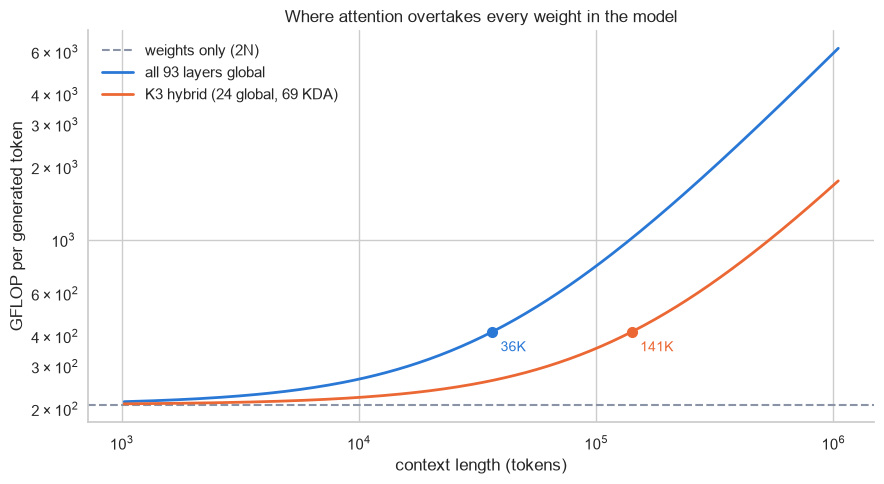

In [13]:
s = np.logspace(np.log10(1024), np.log10(2**20), 200)
per_layer = attn_per_pos / n_mla

hybrid = weight_flops + per_layer * n_mla * s
all_mla = weight_flops + per_layer * cfg.n_layers * s
x_hybrid = weight_flops / (per_layer * n_mla)
x_all = weight_flops / (per_layer * cfg.n_layers)

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(weight_flops / 1e9, color="#8a94a6", ls="--", lw=1.5, label="weights only (2N)")
ax.plot(s, all_mla / 1e9, color=TOTAL, lw=2, label=f"all {cfg.n_layers} layers global")
ax.plot(s, hybrid / 1e9, color=ACTIVE, lw=2, label=f"K3 hybrid ({n_mla} global, {cfg.n_layers - n_mla} KDA)")

for xc, col in [(x_all, TOTAL), (x_hybrid, ACTIVE)]:
    ax.plot(xc, 2 * weight_flops / 1e9, "o", color=col, ms=7, zorder=5)
    ax.annotate(
        f"{xc / 1000:.0f}K",
        (xc, 2 * weight_flops / 1e9),
        textcoords="offset points",
        xytext=(6, -14),
        color=col,
        fontsize=10,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("context length (tokens)")
ax.set_ylabel("GFLOP per generated token")
ax.set_title("Where attention overtakes every weight in the model")
ax.legend(frameon=False, loc="upper left")
sns.despine()
plt.tight_layout()

### Cross-check: hand-derived FLOPs vs the loaded model

Two independent routes to the same number.

**By hand** — `params_by_hand()` in `flops.py` writes out every shape from the
config numbers alone. No torch, no module tree, just `d_model * q_lora_rank` and
friends, summed per component.

**From the model** — `model.breakdown()` walks the actual `nn.Module` tree built
in `models.py` and calls `.numel()`.

If the formula missed a weight, or `models.py` invented one, these disagree. Then
apply rule 1 to whichever we trust.

In [14]:
from flops import params_by_hand

hand = params_by_hand(cfg)
real = model.breakdown()

check = pd.DataFrame({"by hand": hand, "from model": real})
check["diff"] = check["by hand"] - check["from model"]
check.loc["TOTAL"] = [sum(hand.values()), model.total_params(), 0]
check.loc["TOTAL", "diff"] = check.loc["TOTAL", "by hand"] - check.loc["TOTAL", "from model"]
check

,by hand,from model,diff
KDA,30618086496,30618086496,0
Gated MLA,5572706304,5572706304,0
MoE routed,2722740830208,2722740830208,0
MoE shared,12155092992,12155092992,0
MoE down/up,4726980608,4726980608,0
MoE router,591284736,591284736,0
Dense FFN,726663168,726663168,0
Embedding,1174405120,1174405120,0
Output head,1174405120,1174405120,0
Other,2007040,2007040,0


In [15]:
# rule 1 applied to both routes, active params only
hand_active = dict(hand)
hand_active["MoE routed"] = hand["MoE routed"] * cfg.n_active_routed // cfg.n_routed
hand_active["Embedding"] = 0

flops = pd.DataFrame(
    {
        "by hand (GFLOP)": pd.Series(hand_active) * 2 / 1e9,
        "from model (GFLOP)": pd.Series(model.breakdown(active=True)) * 2 / 1e9,
    }
)
flops.loc["TOTAL"] = flops.sum()
flops["diff"] = flops["by hand (GFLOP)"] - flops["from model (GFLOP)"]

print(f"2N by hand      {2 * sum(hand_active.values()) / 1e9:.3f} GFLOP/token")
print(f"2N from model   {2 * model.active_params() / 1e9:.3f} GFLOP/token")
flops.round(3)

2N by hand      208.375 GFLOP/token


2N from model   208.375 GFLOP/token


,by hand (GFLOP),from model (GFLOP),diff
KDA,61.236,61.236,0.0
Gated MLA,11.145,11.145,0.0
MoE routed,97.241,97.241,0.0
MoE shared,24.310,24.310,0.0
MoE down/up,9.454,9.454,0.0
MoE router,1.183,1.183,0.0
Dense FFN,1.453,1.453,0.0
Embedding,0.000,0.000,0.0
Output head,2.349,2.349,0.0
Other,0.004,0.004,0.0


### The rules, collected

| # | Rule | Formula |
|---|---|---|
| 0 | one matmul | `2mkn` (rounds up from `mn(2k-1)`) |
| 1 | a weight, per token | `2 × params` |
| 1a | forward pass | `2N` |
| 1b | training step | `6N` = `2N` fwd + `4N` bwd |
| 2 | attention scores, per token | `2·s·h·(d_qk + d_v)` per global layer |

**Which regime?** Rule 1 is regime-free: every token's hidden state passes
through every weight exactly once whether you batch them (prefill) or stream them
(decode), so `2N = 208.4 GFLOP/token` holds for both.

Rule 2 is not. The numbers above are **decode** — one new token against `s` cached
ones. In prefill the causal mask means the average query attends over only `s/2`
positions, so the per-token attention cost is **half** the decode figure at the
same `s` (total prefill work is still `O(s²)`). That moves the crossover:

| regime | attention per token | crossover |
|---|---|---|
| decode | `2·s·h·(d_qk+d_v)·n_mla` | 141,313 tokens |
| prefill (avg) | half that | 282,627 tokens |

**Caveat — FLOPs stop being the constraint during decode.** Generating one token
requires *reading* all 104.2B active parameters from memory to do only ~208 GFLOP
of work. That ratio makes decode memory-bandwidth-bound, not compute-bound, so
these numbers describe arithmetic rather than wall-clock. They become the real
constraint again during prefill, and for the long-context regime on the right of
the chart above.